In [2]:
import challenge.data as data
from collections import Counter
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap
from collections import Counter

/raid/home/students/fotis/MVA/DLMI-challenge/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
dataset = data.PatchDataset("../data/train.h5", mode="train")
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1)

In [7]:
dataset[0]["img"].min(), dataset[0]["img"].max()

(tensor(0.0510), tensor(1.))

In [ ]:
embds = torch.load("../data/embeddings/train_dinov2_vits14_embeddings.pt")
test_embds = torch.load("../data/embeddings/test_dinov2_vits14_embeddings.pt")

In [8]:
dataset[0].keys()

dict_keys(['img', 'label', 'center'])

In [6]:
X = embds["features"].numpy()
y = embds["labels"].numpy()
c = embds["centers"].numpy()


print("features shape:", X.shape)
print("labels shape:", y.shape)
print("centers shape:", c.shape)
print("center counts:", Counter(c.tolist()))
print("label counts:", Counter(y.tolist()))

features shape: (100000, 384)
labels shape: (100000,)
centers shape: (100000,)
center counts: Counter({4: 43488, 3: 38756, 0: 17756})
label counts: Counter({1: 50220, 0: 49780})


In [18]:
n_max = 10000
rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=n_max, replace=False)
X_plot = X[idx]
y_plot = y[idx]
c_plot = c[idx]

In [19]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

Z = reducer.fit_transform(X_plot)
print("UMAP shape:", Z.shape)

/raid/home/students/fotis/MVA/DLMI-challenge/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (10000, 2)


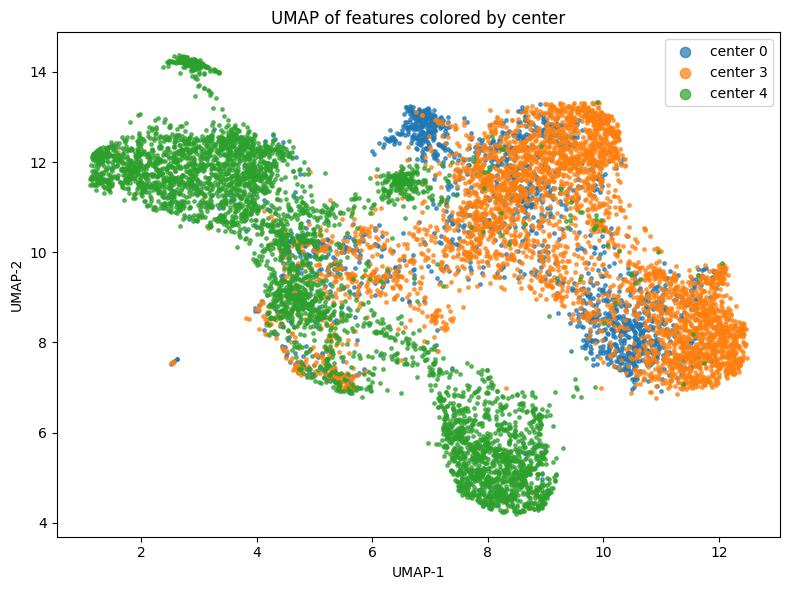

In [20]:
plt.figure(figsize=(8, 6))
for center in np.unique(c_plot):
    mask = c_plot == center
    plt.scatter(
        Z[mask, 0],
        Z[mask, 1],
        s=6,
        alpha=0.7,
        label=f"center {center}",
    )

plt.title("UMAP of features colored by center")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

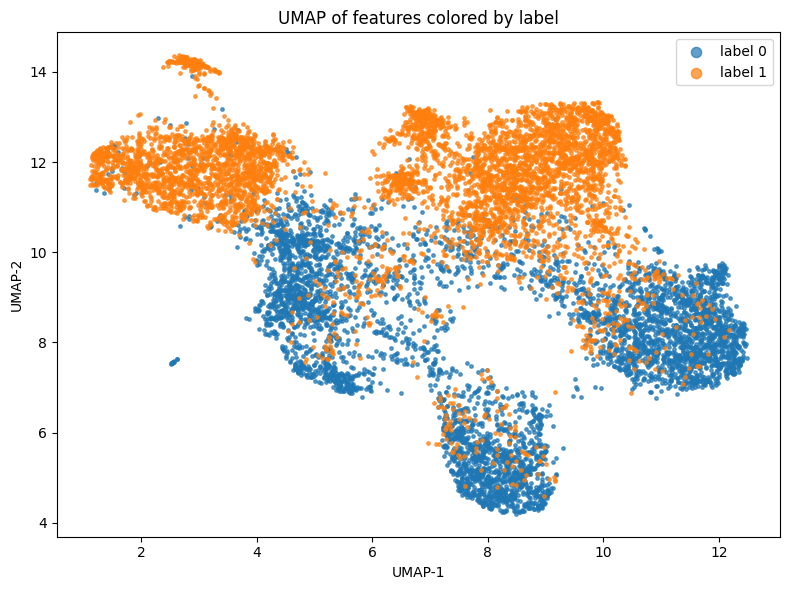

In [23]:
plt.figure(figsize=(8, 6))
for label in np.unique(y_plot):
    mask = y_plot == label
    plt.scatter(
        Z[mask, 0],
        Z[mask, 1],
        s=6,
        alpha=0.7,
        label=f"label {label}",
    )

plt.title("UMAP of features colored by label")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()